## The red wine dataset

The red wine data is available in  <a>https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv</a>

We need to predict the quality of the wine using the features given.

In [27]:
import pandas as pd

red_wine_data = pd.read_csv('data/winequality-red.csv', sep=';')
red_wine_data.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [28]:
red_wine_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [29]:
red_wine_data.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


array([[<Axes: title={'center': 'fixed acidity'}>,
        <Axes: title={'center': 'volatile acidity'}>,
        <Axes: title={'center': 'citric acid'}>],
       [<Axes: title={'center': 'residual sugar'}>,
        <Axes: title={'center': 'chlorides'}>,
        <Axes: title={'center': 'free sulfur dioxide'}>],
       [<Axes: title={'center': 'total sulfur dioxide'}>,
        <Axes: title={'center': 'density'}>,
        <Axes: title={'center': 'pH'}>],
       [<Axes: title={'center': 'sulphates'}>,
        <Axes: title={'center': 'alcohol'}>,
        <Axes: title={'center': 'quality'}>]], dtype=object)

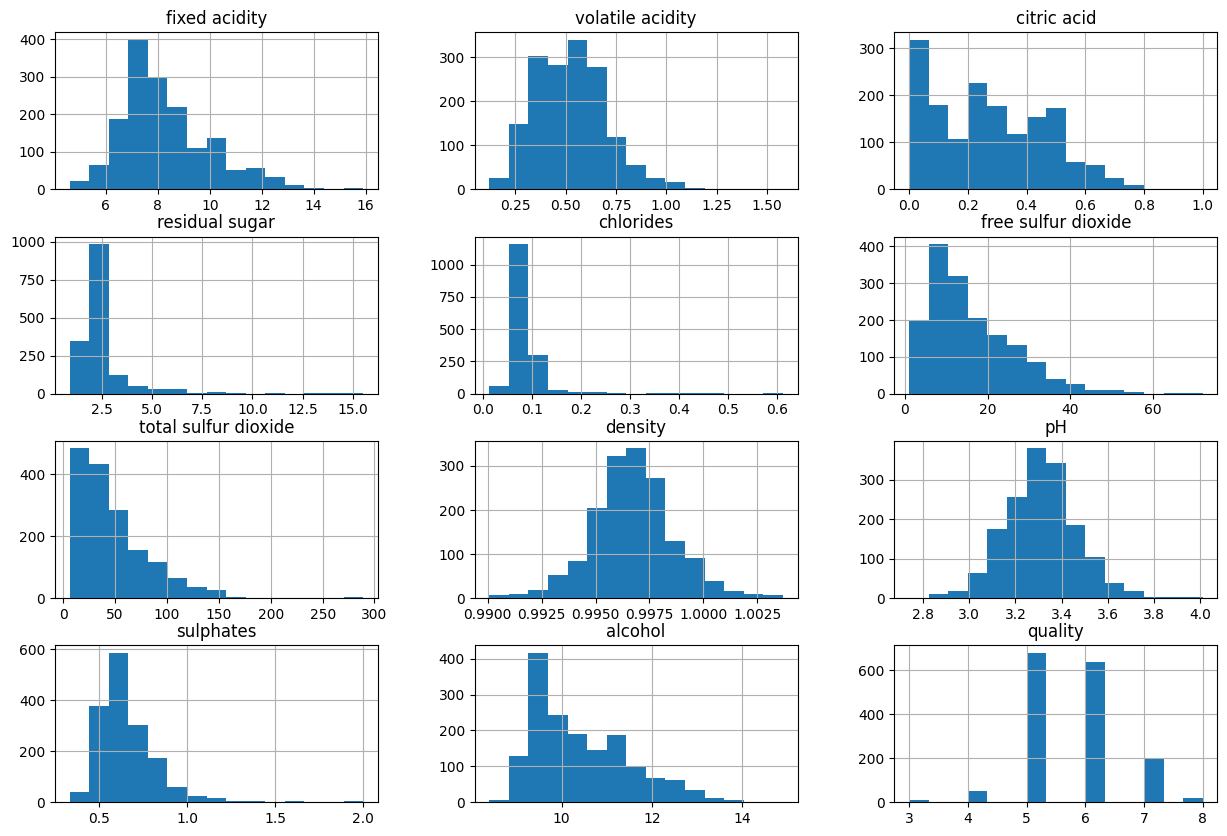

In [30]:
red_wine_data.hist(bins=15, figsize=(15,10))

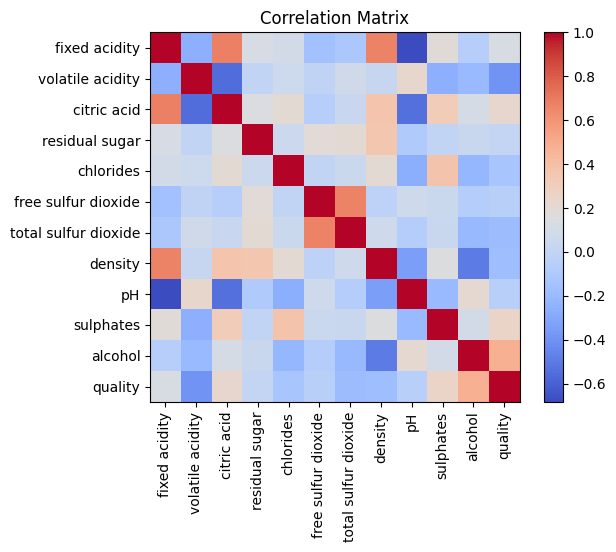

In [31]:
import matplotlib.pyplot as plt

corr = red_wine_data.corr()

plt.imshow(corr, cmap='coolwarm', interpolation='none')

plt.colorbar()
plt.xticks(range(len(corr)), corr.columns, rotation=90)
plt.yticks(range(len(corr)), corr.columns)
plt.title('Correlation Matrix')
plt.show()

We notice that quality ranges from 3 to 8, so we can label encode to get values from 0 to 5 to use with cross entropy loss

In [32]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer

x = red_wine_data.drop('quality', axis=1)
y = red_wine_data['quality']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

preprocessing_pipeline = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), x.columns)
    ]
)

x_train_preprocessed = preprocessing_pipeline.fit_transform(x_train)
x_test_preprocessed = preprocessing_pipeline.transform(x_test)

le = LabelEncoder()

y_train_preprocessed = le.fit_transform(y_train)
y_test_preprocessed = le.transform(y_test)

In [33]:
x_train_preprocessed[:5],y_train_preprocessed[:5]

(array([[ 0.21833164,  0.88971201,  0.19209222,  0.30972563, -0.04964208,
          0.69100692,  1.04293362,  1.84669643,  1.09349989,  0.45822284,
          1.12317723],
        [-1.29016623, -1.78878251,  0.65275338, -0.80507963, -0.45521361,
          2.38847304,  3.59387025, -3.00449133, -0.40043872, -0.40119696,
          1.40827174],
        [ 1.49475291, -0.78434707,  1.01104539, -0.52637831,  0.59927236,
         -0.95796016, -0.99174203,  0.76865471, -0.07566946,  0.51551749,
         -0.58738978],
        [ 0.27635078,  0.86181102, -0.06383064, -0.66572897, -0.00908493,
          0.01202048, -0.71842739,  0.08948842,  0.05423824, -1.08873281,
         -0.96751578],
        [ 0.04427419,  2.81487994, -0.62686095,  2.39998549, -0.31326357,
         -0.47296984,  0.2229897 ,  1.1998714 ,  0.37900751, -0.9741435 ,
         -0.49235828]]),
 array([3, 3, 3, 2, 2]))

In [34]:
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [35]:
x_train_tensor = torch.tensor(x_train_preprocessed, dtype=torch.float)
y_train_tensor = torch.tensor(y_train_preprocessed, dtype=torch.long)
x_test_tensor = torch.tensor(x_test_preprocessed, dtype=torch.float).to(device)
y_test_tensor = torch.tensor(y_test_preprocessed, dtype=torch.long).to(device)

# these create a new tensor from the data provided

In [36]:
from torch.utils.data import TensorDataset, DataLoader

# wrap the tensors in a TensorDataset
train_dataset = TensorDataset(x_train_tensor, y_train_tensor)

# batch data using DataLoader
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

In [37]:
from torch import nn

class WineQualityModel_0(nn.Module):
    def __init__(self, input_dim, output_dim):
        super().__init__()

        self.input_layer = nn.Linear(in_features=input_dim, out_features=33) # we have 11 features and 1 label. We are taking 4 times the input features as hidden units 
        self.hidden_layer_1 = nn.Linear(in_features=33, out_features=33)
        self.hidden_layer_2 = nn.Linear(in_features=33, out_features=33)
        self.output_layer = nn.Linear(in_features=33, out_features=output_dim) # output layer will have 6 unit for the final 1 label.
        self.relu = nn.GELU()

        self.dropout = nn.Dropout(p=0)

    def forward(self, x):
        x = self.input_layer(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.hidden_layer_1(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.hidden_layer_2(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.output_layer(x)
        return x

now that we have the model ready, we will be starting the training loop. The training consists of these steps
1. Moving mpodel and dataset to GPU (if available)
2. loss function (we will use CrossEntropyLoss)
3. optimizer (we can use ADAM, SGD, RMSProp etc, we will use ADAM)
4. Loop through the trainloader and train the model 

In [38]:
model_0 = WineQualityModel_0(input_dim=11, output_dim=6).to(device)

epochs = 200
lr = 0.001
optimizer = torch.optim.Adam(model_0.parameters(), lr = lr)
loss_fn = nn.CrossEntropyLoss()

epoch_count = []
train_loss_values = []
test_loss_values = []

for epoch in range(epochs):

    model_0.train()

    batch_loss = 0
    member_count = 0

    for x_batch, y_batch in train_loader:

        x_batch, y_batch = x_batch.to(device), y_batch.to(device)

        y_logits = model_0(x_batch)

        loss = loss_fn(y_logits, y_batch.long())
        batch_loss += loss.item()
        member_count += 1

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    model_0.eval()

    with torch.inference_mode():
        test_pred = model_0(x_test_tensor)

        test_loss = loss_fn(test_pred, y_test_tensor.type(torch.long))

        epoch_count.append(epoch)
        train_loss_values.append(batch_loss/ member_count)
        test_loss_values.append(test_loss.item())

        if test_loss < 0.8618305325508118:
            best_test_loss = test_loss
            torch.save(model_0.state_dict(), "red_wine_models/best_model.pth")
        
        if epoch % 10 == 0:
            print(f"Epoch : {epoch} \n Train Loss : {batch_loss/ member_count} \n Test Loss : {test_loss.item()} \n")
      


Epoch : 0 
 Train Loss : 1.6556832522153855 
 Test Loss : 1.4913827180862427 

Epoch : 10 
 Train Loss : 0.9161862507462502 
 Test Loss : 0.9343612790107727 

Epoch : 20 
 Train Loss : 0.8750252455472947 
 Test Loss : 0.9037243127822876 

Epoch : 30 
 Train Loss : 0.8480168268084526 
 Test Loss : 0.8980587124824524 

Epoch : 40 
 Train Loss : 0.8228309363126755 
 Test Loss : 0.9057303667068481 

Epoch : 50 
 Train Loss : 0.7965164244174957 
 Test Loss : 0.9012991189956665 

Epoch : 60 
 Train Loss : 0.7609868377447129 
 Test Loss : 0.9022783041000366 

Epoch : 70 
 Train Loss : 0.7290114350616932 
 Test Loss : 0.9265422821044922 

Epoch : 80 
 Train Loss : 0.6932930968701839 
 Test Loss : 0.9357879757881165 

Epoch : 90 
 Train Loss : 0.6618522480130196 
 Test Loss : 0.9666599035263062 

Epoch : 100 
 Train Loss : 0.6215811602771282 
 Test Loss : 1.0207387208938599 

Epoch : 110 
 Train Loss : 0.5892363622784614 
 Test Loss : 1.061287522315979 

Epoch : 120 
 Train Loss : 0.54828926548

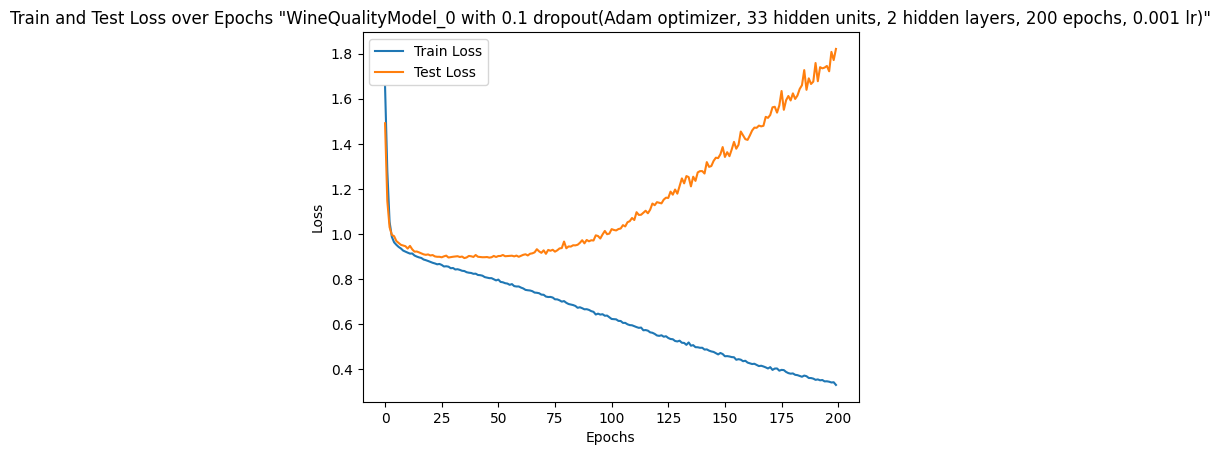

In [39]:
import os
os.makedirs('results_figures', exist_ok=True)

plt.plot(epoch_count, train_loss_values, label='Train Loss')
plt.plot(epoch_count, test_loss_values, label='Test Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Train and Test Loss over Epochs "WineQualityModel_0 with 0.1 dropout(Adam optimizer, 33 hidden units, 2 hidden layers, 200 epochs, 0.001 lr)"')
plt.legend()
plt.savefig('results_figures/WineQualityModel_0 with 0.1 dropout(Adam optimizer, 33 hidden units, 2 hidden layers, 200 epochs, 0.001 lr).png')
plt.show()


In [40]:
import pandas as pd
import os

os.makedirs('results', exist_ok=True)
filename = "results/wine_quality_results.csv"

results = {
    "Model Name" : "WineQualityModel_0 (Adam optimizer with 0.1 dropout, 33 hidden units, 2 hidden layers, 200 epochs, 0.001 lr)",
    "learning rate" : lr,
    "epochs" : epochs,
    "Best train loss" : min(train_loss_values),
    "best train loss epoch" : epoch_count[train_loss_values.index(min(train_loss_values))],
    "Best test loss" : min(test_loss_values),
    "best test loss epoch" : epoch_count[test_loss_values.index(min(test_loss_values))],
    "final train loss" : train_loss_values[-1],
    "final test loss" : test_loss_values[-1],
    "notes" : "Adam optimizer with weight decay and 0.1 dropout attained similar minimum loss as Adam and also overfits like adam over time."
}


if os.path.exists(filename):
    df = pd.read_csv(filename)
    new_row = pd.DataFrame([results])
    df = pd.concat([df, new_row], ignore_index=True)
else:
    df = pd.DataFrame([results])

df.to_csv(filename, index=False)

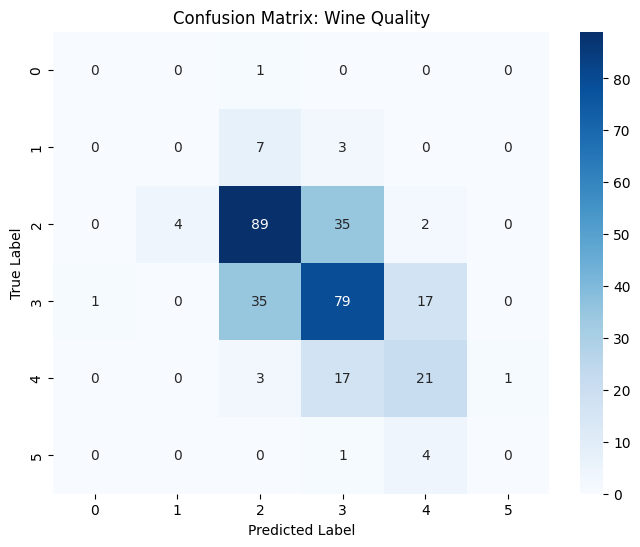

In [41]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

model_0.eval()
with torch.inference_mode():
    y_logits = model_0(x_test_tensor)
    y_preds = torch.argmax(torch.softmax(y_logits, dim=1), dim=1)

# Generate matrix
cm = confusion_matrix(y_test_tensor.cpu(), y_preds.cpu())

# Plot
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix: Wine Quality')
plt.show()

In [42]:
accuracy = (y_preds == y_test_tensor).sum().item() / len(y_test_tensor)
print(f"Test Accuracy: {accuracy * 100:.2f}%")

Test Accuracy: 59.06%


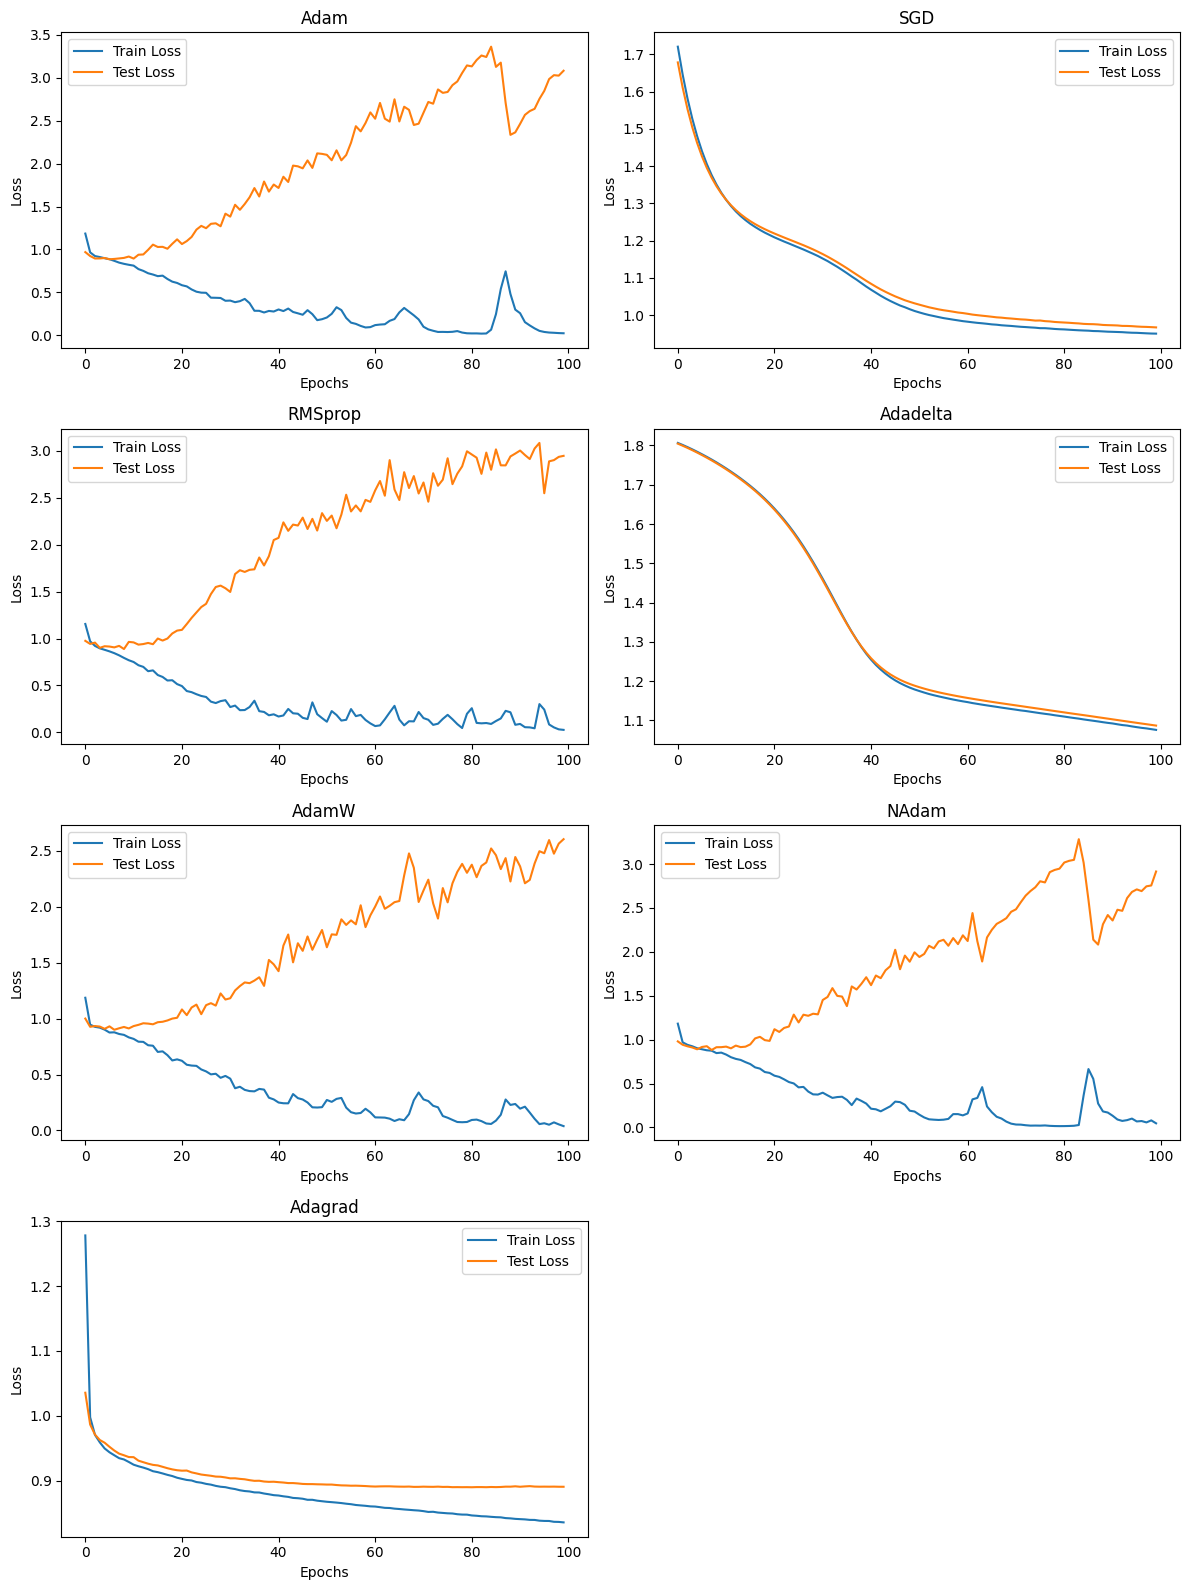

In [43]:
optimizer_list = [torch.optim.Adam, torch.optim.SGD, torch.optim.RMSprop, torch.optim.Adadelta, torch.optim.AdamW, torch.optim.NAdam, torch.optim.Adagrad]

model_0 = WineQualityModel_0(input_dim=11, output_dim=6).to(device)

epochs = 100
lr = 0.01

num_plots = len(optimizer_list)
cols = 2
rows = 4
fig, axes = plt.subplots(rows, cols, figsize=(12, rows*4)) 
axes = axes.flatten()


for i, optimizer_class in enumerate(optimizer_list):
    model_0 = WineQualityModel_0(input_dim=11, output_dim=6).to(device)

    optimizer = optimizer_class(model_0.parameters(), lr=lr)

    epochs = 100
    lr = 0.01
    loss_fn = nn.CrossEntropyLoss()

    epoch_count = []
    train_loss_values = []
    test_loss_values = []

    for epoch in range(epochs):

        model_0.train()

        batch_loss = 0
        member_count = 0

        for x_batch, y_batch in train_loader:

            x_batch, y_batch = x_batch.to(device), y_batch.to(device)

            y_logits = model_0(x_batch)

            loss = loss_fn(y_logits, y_batch.long())
            batch_loss += loss.item()
            member_count += 1

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        model_0.eval()

        with torch.inference_mode():
            test_pred = model_0(x_test_tensor)

            test_loss = loss_fn(test_pred, y_test_tensor.type(torch.long))

            epoch_count.append(epoch)
            train_loss_values.append(batch_loss/ member_count)
            test_loss_values.append(test_loss.item())

            if test_loss < 0.8618305325508118:
                best_test_loss = test_loss
                torch.save(model_0.state_dict(), f"best_model_{optimizer_class.__name__}.pth")

    axes[i].plot(epoch_count, train_loss_values, label='Train Loss')
    axes[i].plot(epoch_count, test_loss_values, label='Test Loss')
    axes[i].set_xlabel('Epochs')
    axes[i].set_ylabel('Loss')
    axes[i].set_title(optimizer_class.__name__)
    axes[i].legend()

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout() 
plt.show()

        


The minimum test loss attained is 0.8395. Currently the accuracy is around 63% with most errors coming from the misclassification of quality 5 wine as 6 and quality 6 wine as 5. Few feature engineering techniques could be tried out on the data and see if we are able to get a better results.

Different ways of feature engineering and pre-processing were tried upon
1. Preprocessing - standard scaler, min max scaler and max abs scaler
2. Feature engineering - total acidity, alcohol-sugar ratio, free sulphur ratio, difference of totral and free sulphur were tried but the results were not improving
3. Optimizer - Adam gives the best results, Adadelta also gave similar results, weight decay of 1e-4 gave a slight improvement, other optimizers like Nadam, RMSProp, SGD were also used, but theyr did not give a good result. 
4. linear layers - 3 hidden layers were present in all models. 44 nodes were set at first, but then reduced till 22. And 22 nodes gave the minimum test loss.
5. activation functions - ReLU, Gelu and LeakyReLu were used and they did not give much differences.
6. Dropout was also tried upon. In some cases they improved the loss. Having dropouts in 1 layers and in 3 layers were tried. But, having high dropouts increased training loss after a point.

The next part is hyperparameter tuning. Although we could try randomly ourselves it is a time consuming work and also error prone. We could use a few methods to tune parameters
1. sklearn gridsearchcv - time consuming and sometimes not practical
2. sklearn randomsearchcv - saves time and finds near optimal solution most of the times
3. Other libraries such as Optuna and Ray Tune provide functionality specific to tuning nerual networks based models. They tune towards the optimal by using the objective history of the model and its parameters set.
